In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
rfm = pd.read_csv("../data/processed/rfm_features.csv")
rfm.head()

,recency,frequency,monetary
0,1,168,3174.62
1,74,19,601.64
2,18,66,1145.35
3,309,17,334.40
4,35,80,1505.74


In [3]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4194 entries, 0 to 4193
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   recency    4194 non-null   int64  
 1   frequency  4194 non-null   int64  
 2   monetary   4194 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 98.4 KB


In [4]:
rfm.describe()

,recency,frequency,monetary
count,4194.000000,4194.000000,4194.000000
mean,91.563662,86.185265,1042.821770
std,99.724342,216.384203,2217.324037
min,0.000000,1.000000,1.900000
25%,17.000000,16.250000,223.082500
50%,50.000000,39.000000,494.580000
75%,143.000000,94.000000,1183.545000
max,373.000000,7628.000000,89434.510000


In [5]:
X = rfm[['recency', 'frequency', 'monetary']].copy()

In [6]:
X['recency'] = np.log1p(X['recency'])
X['frequency'] = np.log1p(X['frequency'])
X['monetary'] = np.log1p(X['monetary'])

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Elbow method for clustering

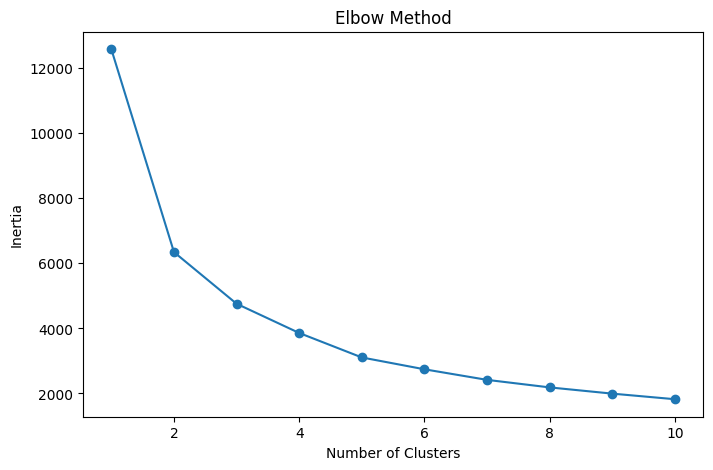

In [9]:
inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [12]:
scores = []

for k in range(2, 8):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores.append((k, score))

    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.4107677748700595
K=3, Silhouette Score=0.317905187288727
K=4, Silhouette Score=0.320235871931498
K=5, Silhouette Score=0.3149002060766457
K=6, Silhouette Score=0.3085796963578327
K=7, Silhouette Score=0.2949851710146013


In [10]:
kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)
clusters = kmeans.fit_predict(X_scaled)
rfm['Cluster'] = clusters

In [14]:
cluster_summary = rfm.groupby('Cluster')[[
    'recency',
    'frequency',
    'monetary'
]].mean()

cluster_summary

,recency,frequency,monetary
Cluster,,,
0,173.945140,10.096246,142.542887
1,18.096173,243.736016,2870.319735
2,128.999246,54.368778,699.243548
3,17.032099,37.667901,461.036654


In [16]:
cluster_labels = {
    0: "Churned Customers",
    1: "VIP Customers",
    2: "At Risk Customers",
    3: "Loyal Customers"
}

rfm['customer_segment'] = rfm['Cluster'].map(cluster_labels)

In [18]:
rfm[['Cluster', 'customer_segment']].head()

,Cluster,customer_segment
0,1,VIP Customers
1,2,At Risk Customers
2,1,VIP Customers
3,2,At Risk Customers
4,1,VIP Customers


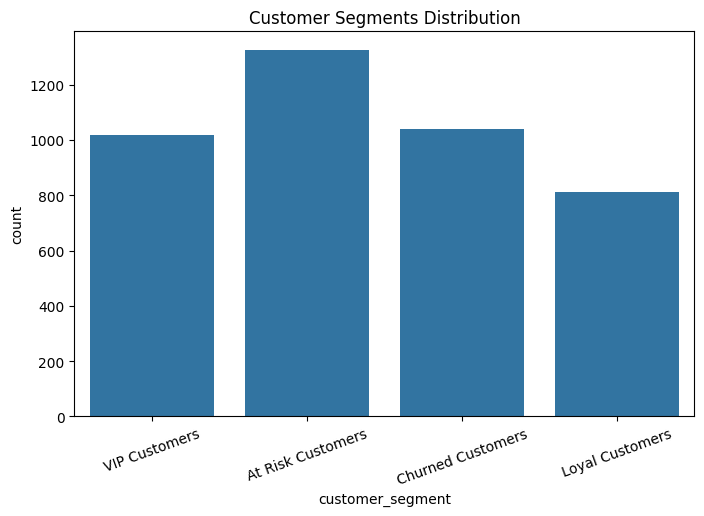

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(data=rfm,x='customer_segment')
plt.xticks(rotation=20)
plt.title("Customer Segments Distribution")
plt.show()

In [23]:
rfm.head()

,recency,frequency,monetary,Cluster,customer_segment
0,1,168,3174.62,1,VIP Customers
1,74,19,601.64,2,At Risk Customers
2,18,66,1145.35,1,VIP Customers
3,309,17,334.40,2,At Risk Customers
4,35,80,1505.74,1,VIP Customers


## DBScan

In [24]:
dbscan = DBSCAN(eps=0.8,min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)
rfm['dbscan_cluster'] = db_labels

In [25]:
rfm['dbscan_cluster'].value_counts()

dbscan_cluster
 0    4188
-1       6
Name: count, dtype: int64

In [26]:
rfm.columns = rfm.columns.str.lower()

In [27]:
rfm.to_csv("../data/processed/rfm_clustered.csv",index=False)